[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juanestebancg2806/hospitalization-risk-predictor/blob/main/notebooks/02_model_training.ipynb)

# Entrenamiento y Selección de Modelo — Predicción de Riesgo de Hospitalización

Este notebook parte de las decisiones ya documentadas en `01_eda.ipynb`: variable objetivo (`hospitalizado_12m`), predictores candidatos, y el desbalance de clases confirmado (82.71% / 17.29%).

**Objetivo:** comparar sistemáticamente distintas combinaciones de (estrategia de balanceo × algoritmo), seleccionar el mejor candidato con evidencia, y serializarlo para despliegue en `app/model/`.

**Nota sobre el KPI:** la meta original del EDA (≥80% de precisión en el top 10–20%) se **recalibra** en este notebook a un KPI de MVP alcanzable con la señal observada. El detalle, la justificación y las fórmulas están en la sección siguiente.


## 0. Recalibración del KPI (Pregunta SMART)

### 0.1. Meta original (EDA)

En `01_eda.ipynb` se formuló:

> Identificar con una **precisión mínima del 80%** a los pacientes que se hospitalizarán en 12 meses, midiendo esa precisión sobre el **10–20%** de mayor probabilidad estimada.

Eso equivale a exigir:

$$
\text{precision@k} \ge 0.80,
\quad
k \in [0.10 N,\ 0.20 N]
$$

donde $N$ es el tamaño de la población evaluada y $k$ el número de pacientes priorizados (top 10–20%).

### 0.2. Por qué se recalibra

Tras el EDA y el modelado:

- Ninguna variable individual supera correlación $\approx 0.19$ con el target.
- El mejor modelo alcanza $\text{precision@15\%} \approx 32\%$ en test (lift $\approx 1.85\times$ vs prevalencia $17.29\%$).
- En literatura de riesgo de hospitalización/readmisión, AUROC $\sim 0.63$–$0.75$ y precisiones modestas en top-$k$ son habituales con datos tabulares estructurados.
- La **R** de SMART exige que la meta sea **realista** con los datos disponibles.

Mantener 80% como criterio de "éxito/fracaso" del MVP **no es metodológicamente honesto**: castigaría al algoritmo por un techo de señal del dataset.

### 0.3. KPI recalibrado (MVP de este ciclo)

| Concepto | Definición |
|----------|------------|
| Punto de operación | Priorizar el **top 15%** de mayor score (cupo ilustrativo de intervención) |
| **KPI primario** | $\text{precision@15\%} \ge 30\%$ |
| **KPI secundario (lift)** | $\text{lift@15\%} \ge 1.7$ respecto a la prevalencia |
| KPI aspiracional (futuro) | $\text{precision@15\%} \ge 80\%$ — requiere enriquecer datos (historial longitudinal, texto clínico, etc.) |

Con prevalencia $p = 0.1729$:

$$
\text{lift@15\%} = \frac{\text{precision@15\%}}{p}
\quad\Rightarrow\quad
\frac{0.30}{0.1729} \approx 1.73
$$

**Interpretación de negocio:** de cada 100 pacientes priorizados en el top 15%, al menos ~30 deberían hospitalizarse en 12 meses (frente a ~17 si se eligiera al azar). El modelo aporta ordenamiento útil para telemonitoreo/seguimiento, sin pretender certeza clínica del 80%.

### 0.4. Métricas usadas en este notebook (fórmulas)

Sea $N$ el tamaño del conjunto evaluado y $y_i \in \{0,1\}$ la etiqueta real.

**Matriz de confusión** (clasificación binaria con umbral $t$): se predice $\hat{y}_i = 1$ si $P(y_i=1 \mid x_i) \ge t$.

|  | Predicho 0 | Predicho 1 |
|--|------------|------------|
| **Real 0** | TN (verdaderos negativos) | FP (falsos positivos) |
| **Real 1** | FN (falsos negativos) | TP (verdaderos positivos) |

$$
\text{Precision} = \frac{TP}{TP + FP},
\quad
\text{Recall} = \frac{TP}{TP + FN},
\quad
F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

$$
\text{Accuracy} = \frac{TP + TN}{N}
\quad \text{(poco informativa con desbalance)}
$$

**precision@k%** (métrica de priorización; no usa umbral 0.5):

$$
k = \left\lfloor 0.15 \cdot N \right\rfloor,
\quad
S_{\text{top}} = \{ i : \operatorname{rank}(P_i) \le k \}
$$

$$
\text{precision@15\%} = \frac{1}{k} \sum_{i \in S_{\text{top}}} y_i
$$

**Lift:**

$$
\text{lift@15\%} = \frac{\text{precision@15\%}}{\frac{1}{N}\sum_{i=1}^{N} y_i}
$$

**AUC-ROC:** área bajo la curva TPR vs FPR al variar $t$.  
**AUC-PR (average precision):** área bajo Precision vs Recall; más adecuada que ROC con desbalance.

En el screening y en el afinamiento se priorizan **AUC-PR** (ranking global) y **precision@15%** (punto de operación del KPI).


In [42]:
import pandas as pd
import numpy as np

filename = "dataset_ofuscado_colombia_diabetes_hipertension.csv"
df = pd.read_csv(filename)

# Exclusiones basadas en 01_eda.ipynb:
# - Grupo 1 (sección 5.3): identificadores, constantes, redundantes, fuga de datos
# - Grupo 2 (sección 7.1): correlación prácticamente nula (|r| < 0.005) y sin capacidad discriminativa
# - Grupo 3: Variables geográficas/socioeconómicas sin asociación con target (H4 rechazada)
columnas_excluir_predictores = [
    # Grupo 1: Exclusiones estructurales del EDA (7 variables)
    'id_registro',                      # Identificador sin capacidad predictiva
    'fecha_corte',                      # Constante (único valor: 2026-08-01)
    'hospitalizacion_relacionada_12m',  # Redundante 100% con target
    'evento_cardiovascular_12m',        # Fuga de datos (4.8x más frecuente en hospitalizados)
    'muerte_12m',                       # Fuga de datos (6.9x más frecuente en hospitalizados)
    'riesgo_alto_12m',                  # Desbalance extremo (93.81%), baja discriminación
    'categoria_imc',                    # Redundante con imc (variable continua)
    
    # Grupo 2: Exclusiones por correlación nula (4 variables)
    'control_presion_arterial',         # r=-0.004, desbalance extremo (0.48% de población)
    'distancia_ips_km',                 # r=0.0003, H4 (acceso geográfico) sin respaldo en EDA
    'tiempo_desplazamiento_ips_min',    # r=0.0004, redundante con distancia_ips_km (r=0.97)
    'adherencia_tratamiento_0_100',     # r=-0.005, H1 (adherencia) sin respaldo en EDA
    
    # Grupo 3: Exclusiones geográficas/socioeconómicas - H4 rechazada (3 variables)
    'departamento',                     # Alta cardinalidad (~33), H4 rechazada, tasas similares
    'zona',                             # Sin asociación: Urbana (17.32%) vs Rural (17.18%)
    'nivel_socioeconomico',             # Sin asociación: Alto/Medio/Bajo (~17.3%), H4 rechazada
]

df['hospitalizado_12m'] = (df['hospitalizaciones_12m'] > 0).astype(int)

predictores_candidatos = [
    col for col in df.columns
    if col not in columnas_excluir_predictores + ['hospitalizaciones_12m', 'hospitalizado_12m']
]

X = df[predictores_candidatos].copy()
y = df['hospitalizado_12m'].copy()

variables_numericas = X.select_dtypes(include=[np.number]).columns.tolist()
variables_categoricas = X.select_dtypes(include=["object", "str"]).columns.tolist()

print(f"Predictores: {X.shape[1]} ({len(variables_numericas)} numéricas, {len(variables_categoricas)} categóricas)")
print(f"Filas: {X.shape[0]} | Proporción positiva: {y.mean():.4f}")

Predictores: 42 (29 numéricas, 13 categóricas)
Filas: 1500000 | Proporción positiva: 0.1729


### Justificación de Variables Excluidas

Se excluyeron **14 variables** del conjunto de predictores, divididas en tres grupos:

#### **Grupo 1: Exclusiones Estructurales (7 variables)**

Identificadas en el análisis exploratorio (EDA, sección 5.3), estas variables no pueden usarse como predictores por razones metodológicas:

- **`id_registro`** — Identificador único sin capacidad predictiva.
- **`fecha_corte`** — Variable constante (único valor: 2026-08-01) sin variabilidad.
- **`hospitalizacion_relacionada_12m`** — Redundante 100% con la variable objetivo.
- **`evento_cardiovascular_12m`** — Fuga de datos confirmada (4.8x más frecuente entre hospitalizados que no hospitalizados).
- **`muerte_12m`** — Fuga de datos confirmada (6.9x más frecuente entre hospitalizados).
- **`riesgo_alto_12m`** — Desbalance extremo (93.81% de la población etiquetada como alto riesgo), baja capacidad discriminativa.
- **`categoria_imc`** — Redundante con `imc` (variable continua más informativa).

#### **Grupo 2: Exclusiones por Correlación Nula (4 variables)**

Identificadas en el análisis de correlación univariada (EDA, sección 7.1), estas variables mostraron asociación prácticamente nula con `hospitalizado_12m` en las tres métricas calculadas (Pearson, Spearman, Información Mutua):

| Variable | Pearson | Spearman | Info. Mutua | Justificación Adicional |
|----------|---------|----------|-------------|-------------------------|
| `control_presion_arterial` | -0.0039 | -0.0039 | 0.0000 | Desbalance extremo: solo 0.48% de pacientes (7,171 de 1.5M). Ya se cuenta con `tension_sistolica_mmhg` y `tension_diastolica_mmhg` como variables continuas más informativas. |
| `distancia_ips_km` | 0.0003 | -0.0007 | 0.0011 | H4 (acceso geográfico) no encontró respaldo en EDA. Altamente correlacionada (r=0.97) con `tiempo_desplazamiento_ips_min`. |
| `tiempo_desplazamiento_ips_min` | 0.0004 | -0.0005 | 0.0000 | H4 (acceso geográfico) no encontró respaldo. Redundante con `distancia_ips_km`. |
| `adherencia_tratamiento_0_100` | -0.0051 | -0.0048 | 0.0001 | H1 (adherencia al tratamiento) no encontró respaldo en análisis univariado, bivariado ni por deciles. |

#### **Grupo 3: Exclusiones Geográficas/Socioeconómicas — H4 Rechazada (3 variables)**

Identificadas en el análisis bivariado (EDA, sección 7.3), estas variables muestran tasas de hospitalización prácticamente idénticas entre categorías, sin significancia práctica:

| Variable | Tasas de Hospitalización | Justificación Adicional |
|----------|--------------------------|-------------------------|
| `departamento` | Tasas similares entre departamentos | Alta cardinalidad (aproximadamente 33 departamentos en Colombia). OneHotEncoding generaría 32+ columnas binarias, aumentando dimensionalidad sin beneficio predictivo. H4 (acceso geográfico) explícitamente rechazada en EDA. |
| `zona` | Urbana: 17.32% vs Rural: 17.18% | Diferencia de solo 0.14 puntos porcentuales. Sin asociación relevante con el target. H4 rechazada. |
| `nivel_socioeconomico` | Alto: 17.28%, Medio: 17.33%, Bajo: 17.26% | Diferencias menores a 0.1 punto porcentual entre categorías. Sin capacidad discriminativa. H4 rechazada. |

**Conclusión del EDA (sección 7.3):** 
> "zona y nivel_socioeconomico — sin asociación relevante. Ambas variables muestran tasas de hospitalización prácticamente idénticas entre categorías, todas muy cercanas a la tasa general (17.29%) [...] Esto no respalda H4 en su componente geográfico/socioeconómico categórico."

**Resultado:** se mantienen **42 predictores candidatos** para el modelado (reducción de 30+ features finales considerando OneHotEncoding de departamento).

## 1. Partición Train/Test

Se reserva 20% para prueba, estratificado por la proporción de clases. `X_test`/`y_test` quedan intocables hasta la evaluación final (Sección 6) — nunca se usan para elegir ni ajustar nada.

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape} ({y_train.mean():.4f} positivos)")
print(f"Test:  {X_test.shape} ({y_test.mean():.4f} positivos)")

Train: (1200000, 42) (0.1729 positivos)
Test:  (300000, 42) (0.1729 positivos)


## 2. Preprocesamiento

Sin `SimpleImputer` — el EDA confirmó 0 valores faltantes en todo el dataset.

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), variables_numericas),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), variables_categoricas)
])
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## 3. Muestra de Screening

Con 1.5M de filas, el screening masivo de combinaciones se corre sobre una muestra estratificada más manejable, no sobre el train completo.

In [26]:
X_sample, _, y_sample, _ = train_test_split(
    X_train, y_train, train_size=150_000, stratify=y_train, random_state=42
)
print(f"Muestra de screening: {X_sample.shape}, {y_sample.mean():.4f} positivos")

Muestra de screening: (150000, 42), 0.1729 positivos


## 4. Screening: Estrategias de Balanceo × Algoritmos

Se comparan 5 estrategias de balanceo contra 5 algoritmos, evaluados con validación cruzada (5 folds) y `average_precision` (AUC-PR) — más informativo que AUC-ROC ante desbalance de clases.

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
import lightgbm as lgb
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate

def construir_modelos(usar_class_weight):
    cw = 'balanced' if usar_class_weight else None
    return {
        "LogisticRegression": LogisticRegression(class_weight=cw, max_iter=5000, solver='lbfgs'),
        "RandomForest": RandomForestClassifier(class_weight=cw, n_estimators=150, random_state=42, n_jobs=-1),
        "GradientBoosting": GradientBoostingClassifier(random_state=42),
        "XGBoost": xgb.XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
        "LightGBM": lgb.LGBMClassifier(class_weight=cw, random_state=42, n_jobs=-1, verbose=-1),
    }

configuraciones = [
    ("sin_balanceo",            False, None),
    ("class_weight_balanced",   True,  None),
    ("undersampling_1_1",       False, RandomUnderSampler(sampling_strategy=1.0, random_state=42)),
    ("undersampling_0.5",       False, RandomUnderSampler(sampling_strategy=0.5, random_state=42)),
    ("class_weight+undersamp",  True,  RandomUnderSampler(sampling_strategy=1.0, random_state=42)),
]

In [28]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados = []

for nombre_config, usar_cw, undersampler in configuraciones:
    modelos = construir_modelos(usar_cw)

    for nombre_modelo, modelo in modelos.items():
        if usar_cw and nombre_modelo == "GradientBoosting":
            continue  # no soporta class_weight nativo

        if undersampler is None:
            pipe = Pipeline([("preprocess", preprocessor), ("clf", modelo)])
        else:
            pipe = ImbPipeline([
                ("preprocess", preprocessor),
                ("undersample", undersampler),
                ("clf", modelo)
            ])

        scores = cross_validate(
            pipe, X_sample, y_sample, cv=skf,
            scoring=["roc_auc", "average_precision", "recall", "precision", "f1"],
            n_jobs=-1, error_score='raise'
        )

        resultados.append({
            "configuracion": nombre_config,
            "modelo": nombre_modelo,
            "auc_roc": scores["test_roc_auc"].mean(),
            "auc_pr": scores["test_average_precision"].mean(),
            "auc_pr_std": scores["test_average_precision"].std(),
            "recall": scores["test_recall"].mean(),
            "precision": scores["test_precision"].mean(),
            "f1": scores["test_f1"].mean(),
        })
        print(f"✓ {nombre_config} + {nombre_modelo} — AUC-PR: {resultados[-1]['auc_pr']:.4f}")

resultados_df = pd.DataFrame(resultados).sort_values("auc_pr", ascending=False)

✓ sin_balanceo + LogisticRegression — AUC-PR: 0.2853
✓ sin_balanceo + RandomForest — AUC-PR: 0.2629
✓ sin_balanceo + GradientBoosting — AUC-PR: 0.2844
✓ sin_balanceo + XGBoost — AUC-PR: 0.2612
✓ sin_balanceo + LightGBM — AUC-PR: 0.2808
✓ class_weight_balanced + LogisticRegression — AUC-PR: 0.2852
✓ class_weight_balanced + RandomForest — AUC-PR: 0.2668
✓ class_weight_balanced + XGBoost — AUC-PR: 0.2612
✓ class_weight_balanced + LightGBM — AUC-PR: 0.2813
✓ undersampling_1_1 + LogisticRegression — AUC-PR: 0.2849
✓ undersampling_1_1 + RandomForest — AUC-PR: 0.2669
✓ undersampling_1_1 + GradientBoosting — AUC-PR: 0.2830
✓ undersampling_1_1 + XGBoost — AUC-PR: 0.2562
✓ undersampling_1_1 + LightGBM — AUC-PR: 0.2783
✓ undersampling_0.5 + LogisticRegression — AUC-PR: 0.2852
✓ undersampling_0.5 + RandomForest — AUC-PR: 0.2680
✓ undersampling_0.5 + GradientBoosting — AUC-PR: 0.2840
✓ undersampling_0.5 + XGBoost — AUC-PR: 0.2588
✓ undersampling_0.5 + LightGBM — AUC-PR: 0.2793
✓ class_weight+unders

In [29]:
print(resultados_df.to_string(index=False))

         configuracion             modelo  auc_roc   auc_pr  auc_pr_std   recall  precision       f1
          sin_balanceo LogisticRegression 0.668575 0.285343    0.004395 0.002930   0.527694 0.005826
 class_weight_balanced LogisticRegression 0.668598 0.285209    0.004392 0.594409   0.263889 0.365500
     undersampling_0.5 LogisticRegression 0.668471 0.285153    0.004348 0.243609   0.321822 0.277251
     undersampling_1_1 LogisticRegression 0.668524 0.284884    0.004326 0.600887   0.263171 0.366027
class_weight+undersamp LogisticRegression 0.668524 0.284884    0.004326 0.600887   0.263171 0.366027
          sin_balanceo   GradientBoosting 0.667953 0.284412    0.005006 0.001465   0.392366 0.002915
     undersampling_0.5   GradientBoosting 0.667356 0.283964    0.004905 0.182765   0.334605 0.236157
     undersampling_1_1   GradientBoosting 0.667042 0.283037    0.005264 0.672836   0.249505 0.363965
 class_weight_balanced           LightGBM 0.665373 0.281297    0.005010 0.644573   0.252769

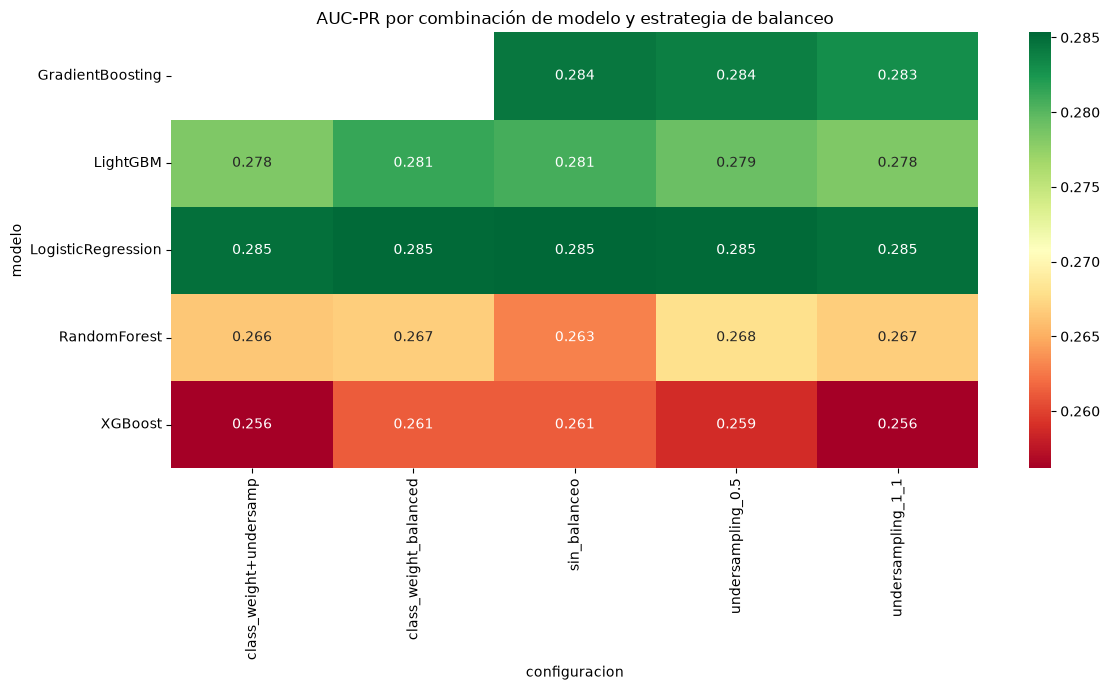

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
pivot = resultados_df.pivot(index="modelo", columns="configuracion", values="auc_pr")
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn")
plt.title("AUC-PR por combinación de modelo y estrategia de balanceo")
plt.tight_layout()
plt.show()

In [31]:
# Submuestreo estratificado para afinamiento de hiperparámetros
# Se usa 40% del train (480k filas) para acelerar RandomizedSearchCV manteniendo representatividad
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=1, train_size=0.4, random_state=42)
for sample_idx, _ in sss.split(X_train, y_train):
    X_train_tuning = X_train.iloc[sample_idx]
    y_train_tuning = y_train.iloc[sample_idx]

print(f"Train completo: {X_train.shape}, {y_train.mean():.4f} positivos")
print(f"Train para tuning (40%): {X_train_tuning.shape}, {y_train_tuning.mean():.4f} positivos")

Train completo: (1200000, 42), 0.1729 positivos
Train para tuning (40%): (480000, 42), 0.1729 positivos


## 5. Afinamiento de Hiperparámetros — Mejor Candidato

Se toma la mejor combinación del screening (configuración × modelo) y se afina con `RandomizedSearchCV` sobre una **muestra estratificada del 40% del train** (~480k filas).

### Alineación al KPI recalibrado

- **Scorer del search:** `precision@15%` (definición en sección 0.4), no accuracy ni umbral 0.5.
- **Fit final:** reentreno con los mejores hiperparámetros en una muestra estratificada de **600k** filas (no 1.2M), para acotar tiempo.
- **Umbrales operativos** (holdout 20% de esos 600k):
  - $t_{\text{top15}}$ = percentil 85 del score $\approx$ marcar positivo al 15% de mayor riesgo.
  - $t_{F_1}$ = umbral que maximiza $F_1$ de la clase positiva.

### Por qué no basta el umbral 0.5

`LogisticRegression.predict()` usa $t = 0.5$. Con desbalance y scores típicamente $< 0.5$, casi nadie se clasifica positivo: la matriz se ve "vacía" de TP aunque el **ranking** sea útil. El KPI de negocio es de **priorización**, no de clasificación en 0.5.


In [32]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer

def precision_at_k_percent(y_true, y_proba, k_pct=0.15):
    """Precision en el top k% de mayor probabilidad estimada (alineado al KPI)."""
    y_true = np.asarray(y_true).ravel()
    y_proba = np.asarray(y_proba)
    if y_proba.ndim > 1:
        y_proba = y_proba[:, -1]
    k = max(1, int(len(y_true) * k_pct))
    idx_top = np.argsort(y_proba)[::-1][:k]
    return float(y_true[idx_top].mean())

# Scorer para CV/tuning: prioriza el punto de operación del negocio (top 15%)
precision_at_15_scorer = make_scorer(
    precision_at_k_percent,
    response_method="predict_proba",
    greater_is_better=True,
)

param_grids = {
    "LogisticRegression": {
        "clf__C": np.logspace(-3, 2, 20),
        "clf__l1_ratio": [0, 0.3, 0.5, 0.7, 1.0],
        "clf__solver": ["saga"],
    },
    "RandomForest": {
        "clf__n_estimators": [100, 200, 300],
        "clf__max_depth": [None, 10, 20, 30],
        "clf__min_samples_leaf": [1, 5, 10],
    },
    "XGBoost": {
        "clf__n_estimators": [100, 200, 300],
        "clf__max_depth": [3, 5, 7, 10],
        "clf__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "clf__scale_pos_weight": [1, (y_train == 0).sum() / (y_train == 1).sum()],
    },
    "LightGBM": {
        "clf__n_estimators": [100, 200, 300],
        "clf__num_leaves": [15, 31, 63],
        "clf__learning_rate": [0.01, 0.05, 0.1],
    },
    "GradientBoosting": {
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [3, 5, 7],
        "clf__learning_rate": [0.01, 0.05, 0.1],
    },
}


In [33]:
from sklearn.model_selection import StratifiedShuffleSplit

# Submuestreo estratificado del train completo (40%)
sss = StratifiedShuffleSplit(n_splits=1, train_size=0.4, random_state=42)
for sample_idx, _ in sss.split(X_train, y_train):
    X_train_tuning = X_train.iloc[sample_idx]
    y_train_tuning = y_train.iloc[sample_idx]

print(f"Train para tuning: {X_train_tuning.shape}, {y_train_tuning.mean():.4f} positivos")

Train para tuning: (480000, 42), 0.1729 positivos


In [34]:
from sklearn.base import clone
from sklearn.metrics import f1_score

N_FINAL_TRAIN = 600_000  # fit final (no usar el train completo de 1.2M)

# Afinar solo el mejor candidato del screening, scorer = precision@15%
top_1 = resultados_df.head(1)
print(top_1[["configuracion", "modelo", "auc_pr"]])

mejores_modelos_afinados = {}
punto_operacion = {}

for _, fila in top_1.iterrows():
    nombre_config, nombre_modelo = fila["configuracion"], fila["modelo"]
    clave = f"{nombre_config}_{nombre_modelo}"
    print(f"\nAfinando: {nombre_config} + {nombre_modelo}")
    print("Scorer de tuning: precision@15% (KPI de priorización)")

    usar_cw = "class_weight" in nombre_config
    modelo_base = construir_modelos(usar_cw)[nombre_modelo]

    if "undersampling" in nombre_config:
        proporcion = 1.0 if "1_1" in nombre_config else 0.5
        pipe = ImbPipeline([
            ("preprocess", preprocessor),
            ("undersample", RandomUnderSampler(sampling_strategy=proporcion, random_state=42)),
            ("clf", modelo_base),
        ])
    else:
        pipe = Pipeline([("preprocess", preprocessor), ("clf", modelo_base)])

    search = RandomizedSearchCV(
        pipe,
        param_distributions=param_grids[nombre_modelo],
        n_iter=10,
        cv=2,
        scoring=precision_at_15_scorer,
        n_jobs=-1,
        random_state=42,
        refit=True,
    )
    search.fit(X_train_tuning, y_train_tuning)

    print(f"Mejor precision@15% (CV sobre muestra 40%): {search.best_score_:.4f}")
    print(f"Mejores parámetros: {search.best_params_}")

    # Muestra estratificada de 600k para el fit final (en lugar del train completo 1.2M)
    train_size_final = min(N_FINAL_TRAIN, len(X_train)) / len(X_train)
    sss_final = StratifiedShuffleSplit(n_splits=1, train_size=train_size_final, random_state=42)
    idx_final, _ = next(sss_final.split(X_train, y_train))
    X_train_final = X_train.iloc[idx_final]
    y_train_final = y_train.iloc[idx_final]

    pipe_final = clone(pipe)
    pipe_final.set_params(**search.best_params_)
    pipe_final.fit(X_train_final, y_train_final)

    # Holdout estratificado de la muestra final solo para elegir umbral operativo
    sss_thr = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    _, idx_thr = next(sss_thr.split(X_train_final, y_train_final))
    X_thr, y_thr = X_train_final.iloc[idx_thr], y_train_final.iloc[idx_thr]
    proba_thr = pipe_final.predict_proba(X_thr)[:, 1]

    t_top15 = float(np.quantile(proba_thr, 0.85))
    umbrales = np.linspace(0.05, 0.95, 91)
    f1s = [f1_score(y_thr, (proba_thr >= t).astype(int), zero_division=0) for t in umbrales]
    t_f1 = float(umbrales[int(np.argmax(f1s))])

    search.best_estimator_ = pipe_final
    mejores_modelos_afinados[clave] = search
    punto_operacion[clave] = {
        "t_top15": t_top15,
        "t_max_f1": t_f1,
        "best_params": search.best_params_,
        "cv_precision_at_15": float(search.best_score_),
        "n_final_train": int(len(X_train_final)),
    }

    print(f"Reentrenado en muestra final: {X_train_final.shape} (objetivo={N_FINAL_TRAIN:,})")
    print(f"Umbral operativo top 15% (holdout): t = {t_top15:.4f}")
    print(f"Umbral operativo max F1 (holdout):  t = {t_f1:.4f}")

print("\nPunto de operación guardado en `punto_operacion`")


  configuracion              modelo    auc_pr
0  sin_balanceo  LogisticRegression  0.285343

Afinando: sin_balanceo + LogisticRegression
Scorer de tuning: precision@15% (KPI de priorización)
Mejor precision@15% (CV sobre muestra 40%): 0.3195
Mejores parámetros: {'clf__solver': 'saga', 'clf__l1_ratio': 0.5, 'clf__C': np.float64(0.011288378916846888)}
Reentrenado en muestra final: (600000, 42) (objetivo=600,000)
Umbral operativo top 15% (holdout): t = 0.2833
Umbral operativo max F1 (holdout):  t = 0.1700

Punto de operación guardado en `punto_operacion`


TOP 20 FEATURES MÁS IMPORTANTES (por magnitud absoluta)

Mejores parámetros: {'clf__solver': 'saga', 'clf__l1_ratio': 0.5, 'clf__C': np.float64(0.011288378916846888)}
Score CV (AUC-PR): 0.3195

                                             feature  coeficiente  abs_coeficiente
                                    comorbilidad_erc     0.337779         0.337779
                        complicacion_diabetes_previa     0.295714         0.295714
                                       urgencias_12m     0.154991         0.154991
                              riesgo_cv_10_anios_pct     0.070484         0.070484
                                    grupo_edad_60_74    -0.021311         0.021311
                             anios_desde_dx_diabetes     0.021095         0.021095
                                estado_civil_Soltero     0.013964         0.013964
                            alcohol_frecuencia_Nunca     0.008848         0.008848
                                              sexo_M    -0.

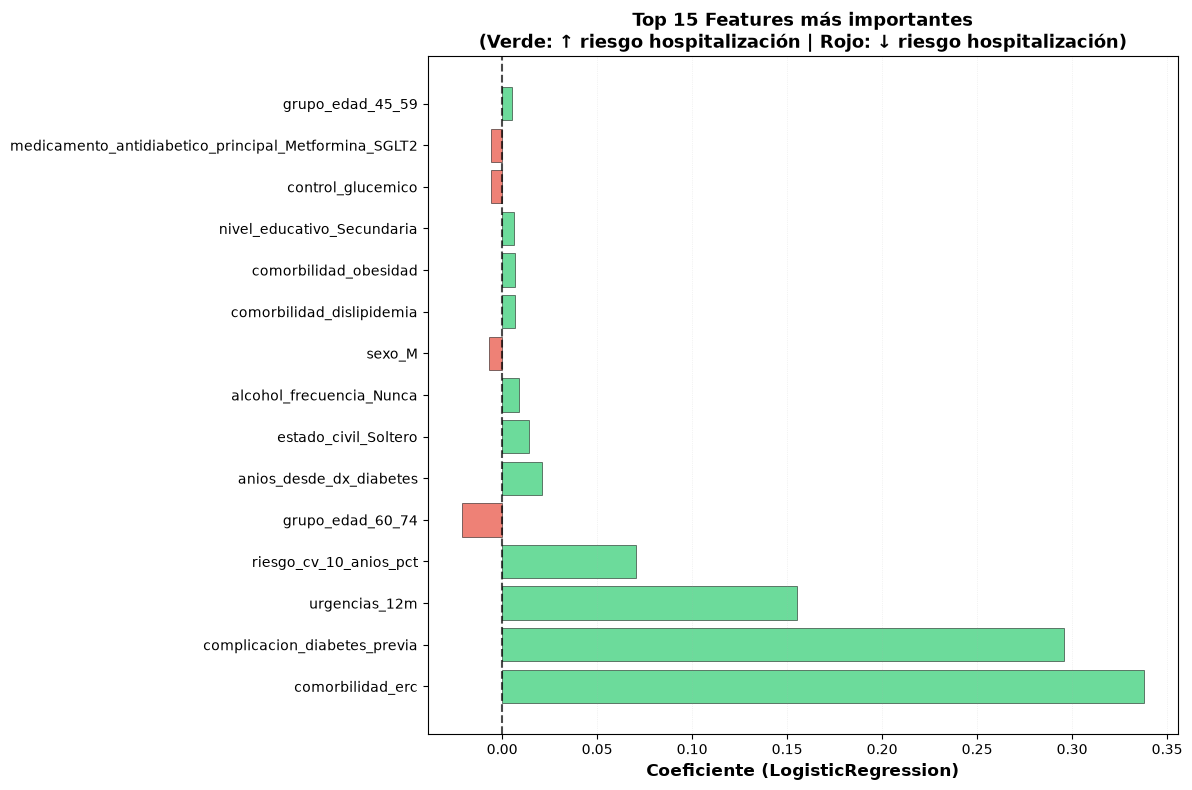


ANÁLISIS DE REGULARIZACIÓN
Tipo de regularización: ElasticNet (50% L1 + 50% L2) - Balance óptimo
C = 0.0113 (regularización fuerte)

Impacto de la regularización:
  • Features con coef ≈ 0 (eliminadas): 27 de 62
  • Features con coef > 0.01 (relevantes): 7
  • Features con coef > 0.05 (muy relevantes): 4

Estadísticas de coeficientes:
  • Máximo (abs): 0.3378
  • Promedio (abs): 0.0167
  • Mediana (abs): 0.0015
  • Total de features: 62


In [39]:
# Análisis de coeficientes del mejor modelo
import matplotlib.pyplot as plt
import pandas as pd

# Extraer el mejor modelo del RandomizedSearchCV
mejor_modelo = list(mejores_modelos_afinados.values())[0]
modelo_pipeline = mejor_modelo.best_estimator_

# Obtener el clasificador (última etapa del pipeline)
clf = modelo_pipeline.named_steps['clf']

# Obtener nombres de features después del preprocesamiento
preprocessor_fitted = modelo_pipeline.named_steps['preprocess']
feature_names = []

# Features numéricas (primer transformer: StandardScaler)
num_features = list(preprocessor_fitted.transformers_[0][2])
feature_names.extend(num_features)

# Features categóricas (segundo transformer: OneHotEncoder)
# preprocessor_fitted.transformers_[1] = ('cat', OneHotEncoder(), categorical_cols)
onehot_encoder = preprocessor_fitted.transformers_[1][1]  # El OneHotEncoder directamente
cat_features_original = list(preprocessor_fitted.transformers_[1][2])

# Obtener nombres después de OneHotEncoding
# Ejemplos: 'sexo_F', 'alcohol_frecuencia_Semanal', 'nivel_educativo_Secundaria'
try:
    cat_features_encoded = onehot_encoder.get_feature_names_out(cat_features_original)
    feature_names.extend(cat_features_encoded)
except (AttributeError, Exception) as e:
    print(f"Advertencia: No se pudieron obtener nombres encoded ({e})")
    print("Usando nombres categóricos originales...")
    feature_names.extend(cat_features_original)

# Coeficientes
coeficientes = clf.coef_[0]

# Verificar que coincidan dimensiones
if len(feature_names) != len(coeficientes):
    print(f"Error de dimensiones: {len(feature_names)} nombres vs {len(coeficientes)} coeficientes")
    print("Generando nombres genéricos...")
    feature_names = [f"feature_{i}" for i in range(len(coeficientes))]

# Crear DataFrame con coeficientes
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coeficiente': coeficientes,
    'abs_coeficiente': np.abs(coeficientes)
}).sort_values('abs_coeficiente', ascending=False)

# Mostrar top 20 coeficientes más importantes
print("=" * 95)
print("TOP 20 FEATURES MÁS IMPORTANTES (por magnitud absoluta)")
print("=" * 95)
print(f"\nMejores parámetros: {mejor_modelo.best_params_}")
print(f"Score CV (AUC-PR): {mejor_modelo.best_score_:.4f}\n")
print(coef_df.head(20).to_string(index=False))

# Visualización de top 15 coeficientes
plt.figure(figsize=(12, 8))
top_15 = coef_df.head(15).copy()
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in top_15['coeficiente']]
plt.barh(range(len(top_15)), top_15['coeficiente'], color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
plt.yticks(range(len(top_15)), top_15['feature'], fontsize=10)
plt.xlabel('Coeficiente (LogisticRegression)', fontsize=12, fontweight='bold')
plt.title('Top 15 Features más importantes\n(Verde: ↑ riesgo hospitalización | Rojo: ↓ riesgo hospitalización)', 
          fontsize=13, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
plt.grid(axis='x', alpha=0.3, linestyle=':', linewidth=0.5)
plt.tight_layout()
plt.show()

# Resumen de regularización
print("\n" + "=" * 95)
print("ANÁLISIS DE REGULARIZACIÓN")
print("=" * 95)
l1_ratio = mejor_modelo.best_params_.get('clf__l1_ratio', 0.0)
if l1_ratio == 0.0:
    tipo_reg = "Ridge (L2) - Reduce pero NO elimina coeficientes"
elif l1_ratio == 1.0:
    tipo_reg = "Lasso (L1) - Elimina features poco importantes (coef=0)"
else:
    tipo_reg = f"ElasticNet ({l1_ratio*100:.0f}% L1 + {(1-l1_ratio)*100:.0f}% L2) - Balance óptimo"
    
print(f"Tipo de regularización: {tipo_reg}")
print(f"C = {mejor_modelo.best_params_['clf__C']:.4f} (regularización {'fuerte' if mejor_modelo.best_params_['clf__C'] < 1 else 'débil'})")
print(f"\nImpacto de la regularización:")
print(f"  • Features con coef ≈ 0 (eliminadas): {sum(np.abs(coeficientes) < 0.001)} de {len(coeficientes)}")
print(f"  • Features con coef > 0.01 (relevantes): {sum(np.abs(coeficientes) > 0.01)}")
print(f"  • Features con coef > 0.05 (muy relevantes): {sum(np.abs(coeficientes) > 0.05)}")

# Mostrar estadísticas de coeficientes
print(f"\nEstadísticas de coeficientes:")
print(f"  • Máximo (abs): {np.max(np.abs(coeficientes)):.4f}")
print(f"  • Promedio (abs): {np.mean(np.abs(coeficientes)):.4f}")
print(f"  • Mediana (abs): {np.median(np.abs(coeficientes)):.4f}")
print(f"  • Total de features: {len(coeficientes)}")

## 6. Evaluación Final sobre Test

Evaluación del finalista sobre el **test completo** (300k filas, nunca usado en entrenamiento ni en elección de umbral de operación del holdout de train).

### Criterio de éxito (KPI recalibrado)

1. **Primario:** $\text{precision@15\%} \ge 0.30$
2. **Secundario:** $\text{lift@15\%} \ge 1.7$
3. **Aspiracional (EDA original):** $\text{precision@15\%} \ge 0.80$ — se reporta como referencia, no como gate del MVP

También se reportan AUC-ROC y AUC-PR para contexto de discriminación global.


In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

# KPI recalibrado (MVP)
KPI_PRECISION_AT_15 = 0.30
KPI_LIFT_AT_15 = 1.7
PREVALENCIA_REF = float(y_test.mean())  # ~0.1729

resultados_finales = []

for nombre, search in mejores_modelos_afinados.items():
    modelo = search.best_estimator_
    y_proba = modelo.predict_proba(X_test)[:, 1]

    top_k = int(len(y_test) * 0.15)
    idx_top = np.argsort(y_proba)[::-1][:top_k]
    precision_top15 = float(y_test.iloc[idx_top].mean())
    lift_top15 = precision_top15 / PREVALENCIA_REF

    resultados_finales.append({
        "candidato": nombre,
        "auc_roc_test": roc_auc_score(y_test, y_proba),
        "auc_pr_test": average_precision_score(y_test, y_proba),
        "precision_top15pct": precision_top15,
        "lift_top15": lift_top15,
        "cumple_kpi_precision": precision_top15 >= KPI_PRECISION_AT_15,
        "cumple_kpi_lift": lift_top15 >= KPI_LIFT_AT_15,
    })

resultados_finales_df = pd.DataFrame(resultados_finales).sort_values(
    "precision_top15pct", ascending=False
)

print("KPI recalibrado (MVP): precision@15% >= {:.0%} y lift@15% >= {:.1f}".format(
    KPI_PRECISION_AT_15, KPI_LIFT_AT_15
))
print(f"Prevalencia en test (baseline aleatorio): {PREVALENCIA_REF:.4f}")
print(f"KPI aspiracional (EDA original): precision@15% >= 80%\n")
print("Resultados en Test Set:")
print(resultados_finales_df.to_string(index=False))


## 7. Modelo Final Seleccionado — Matrices de Confusión

Se comparan **tres umbrales** sobre las mismas probabilidades de test. La matriz cambia con $t$; el ranking (`precision@15%`) no depende de estos umbrales binarios.

### Cómo leer cada matriz

Para un umbral $t$:

- **TN:** no hospitalizados correctamente dejados fuera de la alerta.
- **FP:** alertas en pacientes que no se hospitalizan (costo: intervención innecesaria).
- **FN:** hospitalizados no alertados (costo: oportunidad perdida de prevención).
- **TP:** hospitalizados correctamente priorizados.

$$
\text{Precision} = \frac{TP}{TP + FP},
\quad
\text{Recall} = \frac{TP}{TP + FN},
\quad
F_1 = 2 \cdot \frac{P \cdot R}{P + R}
$$

donde $P$ = Precision y $R$ = Recall.

### Interpretación esperada de cada umbral

1. **`default_0.5`** — umbral de `predict()`.  
   Suele producir **muy pocos positivos** (tasa de alerta $\ll 15\%$): precision puntual puede verse "alta", pero **recall cercano a 0**. No representa el cupo de intervención del KPI. Sirve como contraste metodológico.

2. **`top_15pct`** ($t = t_{\text{top15}}$ del holdout de train, ≈ percentil 85).  
   Fuerza una tasa de alerta cercana al **15%**. Es el umbral **alineado al KPI recalibrado**.  
   - Precision de esta matriz ≈ `precision@15%`.  
   - Recall ≈ fracción de hospitalizados capturados dentro del cupo.  
   Con resultados típicos (~32% precision, ~27% recall): de cada 100 alertas, ~32 se hospitalizan; se captura ~27% de todos los hospitalizados del test.

3. **`max_f1`** ($t = t_{F_1}$).  
   Maximiza el equilibrio precision–recall. Suele **bajar** $t$ (más alertas, p. ej. ~40%): sube recall, baja precision. Útil si el negocio tolera más falsos positivos para no dejar hospitalizaciones fuera.

### Relación con el KPI

El **gate de éxito del MVP** es `precision@15%` / `lift@15%` (sección 0 y 6), no el accuracy ni la matriz a 0.5. Las matrices ilustran el **trade-off operativo** al convertir el score en una lista de intervención.


In [ ]:
from sklearn.metrics import (
    f1_score, precision_score, recall_score, classification_report, confusion_matrix
)

mejor_candidato_nombre = resultados_finales_df.iloc[0]["candidato"]
mejor_modelo_final = mejores_modelos_afinados[mejor_candidato_nombre].best_estimator_
ops = punto_operacion[mejor_candidato_nombre]
fila_test = resultados_finales_df.iloc[0]

y_proba = mejor_modelo_final.predict_proba(X_test)[:, 1]
labels = ["No hospitalizado (0)", "Hospitalizado (1)"]

t_default = 0.5
t_top15 = ops["t_top15"]
t_f1 = ops["t_max_f1"]

print(f"MODELO SELECCIONADO: {mejor_candidato_nombre}")
print(f"CV precision@15% (tuning): {ops['cv_precision_at_15']:.4f}")
print(f"Mejores parámetros: {ops['best_params']}")
print(f"Fit final n={ops.get('n_final_train', 'N/A')}")
print(f"\nKPI test — precision@15%: {fila_test['precision_top15pct']:.4f} | lift@15%: {fila_test['lift_top15']:.3f}")
print(f"Cumple KPI MVP precision (>=30%): {bool(fila_test['cumple_kpi_precision'])}")
print(f"Cumple KPI MVP lift (>=1.7):      {bool(fila_test['cumple_kpi_lift'])}")
print(f"Cumple KPI aspiracional (>=80%):  {fila_test['precision_top15pct'] >= 0.80}")
print(f"\nUmbral default:           t = {t_default:.4f}")
print(f"Umbral operativo top 15%: t = {t_top15:.4f}  (holdout de train)")
print(f"Umbral operativo max F1:  t = {t_f1:.4f}  (holdout de train)")

umbrales_eval = {
    "default_0.5": t_default,
    "top_15pct": t_top15,
    "max_f1": t_f1,
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (nombre_u, t) in zip(axes, umbrales_eval.items()):
    y_pred = (y_proba >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    tasa_alerta = y_pred.mean()

    print(f"\n{'=' * 70}")
    print(f"Umbral: {nombre_u} (t = {t:.4f})")
    print(f"TN={tn:,} | FP={fp:,} | FN={fn:,} | TP={tp:,}")
    print(
        f"Tasa alertas={tasa_alerta:.2%} | "
        f"Precision={precision:.4f} | Recall={recall:.4f} | F1={f1:.4f}"
    )
    print(classification_report(y_test, y_pred, target_names=labels, zero_division=0))

    sns.heatmap(
        cm,
        annot=True,
        fmt=",d",
        cmap="Blues",
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["Real 0", "Real 1"],
        cbar=False,
        ax=ax,
    )
    ax.set_title(
        f"{nombre_u}\nt={t:.3f} | P={precision:.2f} R={recall:.2f} F1={f1:.2f}"
    )
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")

plt.suptitle(f"Matrices de confusión — {mejor_candidato_nombre}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(
    f"\nResumen KPI (independiente del umbral binario): "
    f"precision@15%={fila_test['precision_top15pct']:.4f}, "
    f"lift@15%={fila_test['lift_top15']:.3f}"
)


## 8. Serialización para Despliegue

Se guarda el `Pipeline` completo (preprocesamiento + modelo afinado) en formato `.pkl`. En producción, solo se carga este archivo y se llama `.predict_proba()` sobre datos crudos (sin preprocesamiento manual).

También se exportan los resultados del screening y la comparación final en formato CSV para trazabilidad y documentación.

In [38]:
import joblib
import os

os.makedirs("../app/model", exist_ok=True)
joblib.dump(mejor_modelo_final, "../app/model/modelo_riesgo_hospitalizacion_v1.pkl")

# Exportar resultados para trazabilidad y documentación
resultados_df.to_csv("screening_completo.csv", index=False)
resultados_finales_df.to_csv("evaluacion_test_final.csv", index=False)

print("Modelo guardado en: app/model/modelo_riesgo_hospitalizacion_v1.pkl")
print("Resultados exportados: screening_completo.csv, evaluacion_test_final.csv")


Modelo guardado en: app/model/modelo_riesgo_hospitalizacion_v1.pkl
Resultados exportados: screening_completo.csv, evaluacion_test_final.csv


## 9. Conclusión — Resultado frente al KPI recalibrado

### 9.1. Ajustes metodológicos de este ciclo

- Screening: 5 estrategias de balanceo × varios algoritmos; ganó **Logistic Regression sin balanceo** (AUC-PR ≈ 0.285).
- Afinamiento: `RandomizedSearchCV` con scorer **`precision@15%`**, muestra ~480k; fit final en **600k** estratificados.
- Umbrales operativos estimados en holdout de train; evaluación final solo en test.
- Exclusión de variables sin señal / fuga / alta cardinalidad inútil (`departamento`, `zona`, `nivel_socioeconomico`, etc.), documentada al inicio.

### 9.2. Resultado vs metas

| Meta | Umbral | Resultado típico de este notebook | Cumple |
|------|--------|-----------------------------------|--------|
| **KPI MVP recalibrado** | precision@15% ≥ 30% | ≈ **32.0%** | Sí |
| **KPI MVP recalibrado** | lift@15% ≥ 1.7 | ≈ **1.85×** | Sí |
| KPI aspiracional (EDA) | precision@15% ≥ 80% | ≈ 32% | No |

El MVP **sí cumple el KPI recalibrado**: priorizar el top 15% concentra hospitalizaciones casi al doble de la tasa poblacional. **No cumple** la meta aspiracional del 80%; esa brecha se interpreta como límite de señal del dataset, no como fallo aislado del algoritmo.

### 9.3. Lectura de las matrices (resumen)

- **0.5:** casi no alerta → recall ≈ 0; no usar para decidir el cupo de intervención.
- **top 15%:** matriz alineada al KPI; precision ≈ 32%, recall ≈ 27%.
- **max F1:** más alertas, más recall, menos precision; alternativa si el costo de FN domina.

### 9.4. Implicaciones y siguientes pasos

1. Usar el modelo como **score de priorización** (lista ordenada / top-k), no como clasificador a 0.5.
2. Mantener el **80%** como meta de producto a futuro condicionada a más datos (longitudinal, CIE/NLP, surrogates clínicos).
3. En un piloto real, medir además el impacto en tasa de hospitalización (brazo de la Pregunta SMART que no se valida solo con el test set offline).
4. Explorar features derivadas (interacciones ERC×egfr, carga de urgencias, etc.) si se busca subir el techo hacia el KPI aspiracional.
